In [2]:
from pylamost import lamost

lm = lamost(token="lLY1albuoI", dr_version="dr12", sub_version="v1.0", is_dev=False)
lm.download_fits(obsid=101012)

'.//spec-55859-F5902_sp01-012.fits.gz'

In [3]:
import gzip
import shutil
import os

# 原始压缩文件路径
compressed_file = r'D:\Spectra_denoise\pylamost-master\pylamost-master\spec-55859-F5902_sp01-012.fits.gz'

# 解压后的文件路径
output_dir = r'D:\Spectra_denoise\spectrum_final'
os.makedirs(output_dir, exist_ok=True)  # 确保目标目录存在

output_file = os.path.join(output_dir, 'spec-55859-F5902_sp01-012.fits')

# 检查压缩文件是否存在
if not os.path.exists(compressed_file):
    print(f"❌ 文件不存在：{compressed_file}")
else:
    try:
        with gzip.open(compressed_file, 'rb') as f_in:
            with open(output_file, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print(f"✅ 解压成功！文件已保存至：\n    {output_file}")
    except Exception as e:
        print(f"❌ 解压失败：{e}")

✅ 解压成功！文件已保存至：
    D:\Spectra_denoise\spectrum_final\spec-55859-F5902_sp01-012.fits


In [4]:
from astropy.io import fits

# 正确的文件路径（请根据实际情况修改）
file_path = r'D:\Spectra_denoise\spectrum_final\spec-55859-F5902_sp01-012.fits'

try:
    with fits.open(file_path) as hdul:
        # 显示文件结构
        hdul.info()
        
        # 读取主数据（通常是第一个HDU）
        data = hdul[0].data
        header = hdul[0].header
        
        print("数据形状:", data.shape)
        print("头部信息示例:")
        print(header[:10])  # 打印前10个header条目
        
except FileNotFoundError:
    print(f"文件未找到，请检查路径是否正确：{file_path}")
except Exception as e:
    print(f"读取文件时出错：{e}")

Filename: D:\Spectra_denoise\spectrum_final\spec-55859-F5902_sp01-012.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     123   ()      
  1  COADD         1 BinTableHDU     30   1R x 6C   [3908E, 3908E, 3908E, 3908E, 3908E, 3908E]   
读取文件时出错：'NoneType' object has no attribute 'shape'


In [7]:
from astropy.io import fits

file_path = r'D:\Spectra_denoise\spectrum_final\spec-55859-F5902_sp01-012.fits'

with fits.open(file_path) as hdul:
    # 查看文件结构（可选）
    hdul.info()
    
    # 读取第1个扩展（COADD）的数据和 header
    table = hdul[1].data   # 表格数据
    header = hdul[1].header  # header 信息

# -------------------- 输出结果 --------------------

# 1. 打印 COADD 扩展的 header
print("\n" + "="*50)
print("HDU[1] HEADER 信息:")
print("="*50)
print(repr(header))  # 使用 repr 避免截断，完整显示

# 2. 打印列名
print("\n" + "="*50)
print("表格列名:")
print("="*50)
print(table.columns.names)

# 3. 提取 FLUX 和 NORMALIZATION 的前 10 个值
# 注意：字段名可能大小写不敏感，但推荐使用大写（FITS 标准）

try:
    flux = table['FLUX']
    print("\nFLUX 前 10 个值:")
    print(flux[:10])
except KeyError:
    print("\n❌ 列 'FLUX' 不存在！请检查列名。")

try:
    norm = table['NORMALIZATION']
    print("\nNORMALIZATION 前 10 个值:")
    print(norm[:10])
except KeyError:
    print("\n❌ 列 'NORMALIZATION' 不存在！请检查列名。")

# 4. 波长列（常见名称：WAVELENGTH, WAVE, LOGWAVE 等）
# 你可以根据上面打印的列名调整
wavelength_cols = ['WAVELENGTH', 'WAVE', 'LAMBDA', 'loglam']
wave = None
for col in wavelength_cols:
    if col in table.columns.names:
        wave = table[col]
        print(f"\n使用波长列: {col}")
        break

if wave is not None:
    print("波长范围:", wave.min(), "to", wave.max())
else:
    print("\n❌ 未找到波长列！支持的名称:", wavelength_cols)

# 5. 流量形状
if 'FLUX' in table.columns.names:
    print("流量形状:", flux.shape)

Filename: D:\Spectra_denoise\spectrum_final\spec-55859-F5902_sp01-012.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     123   ()      
  1  COADD         1 BinTableHDU     30   1R x 6C   [3908E, 3908E, 3908E, 3908E, 3908E, 3908E]   

HDU[1] HEADER 信息:
XTENSION= 'BINTABLE'           /Binary table written by MWRFITS v1.11b          
BITPIX  =                    8 /Required value                                  
NAXIS   =                    2 /Required value                                  
NAXIS1  =                93792 /Number of bytes per row                         
NAXIS2  =                    1 /Number of rows                                  
PCOUNT  =                    0 /Normally 0 (no varying arrays)                  
GCOUNT  =                    1 /Required value                                  
TFIELDS =                    6 /Number of columns in table                      
COMMENT                                        

In [9]:
import numpy as np
from astropy.io import fits
from scipy.interpolate import interp1d
import pandas as pd

# =================== 1. 读取 FITS 光谱文件 ===================
file_path = r'D:\Spectra_denoise\spectrum_final\spec-55859-F5902_sp01-012.fits'

with fits.open(file_path) as hdul:
    table = hdul[1].data   # COADD 扩展，形状 (1,)
    header = hdul[1].header

# 提取原始波长和流量（注意：每列是 object 类型，包含一个数组）
# 常见列名
flux_col = 'FLUX'
wavelength_cols = ['loglam', 'WAVE', 'WAVELENGTH', 'LAMBDA']

# 提取 FLUX 数组（它是 table[flux_col][0]，因为只有一行）
try:
    flux = table[flux_col][0]  # 取第0行的数组
except IndexError:
    raise ValueError(f"无法提取 '{flux_col}' 列的数据，请检查列是否存在或格式是否正确。")

# 查找波长列
original_wave = None
for col in wavelength_cols:
    if col in table.columns.names:
        original_wave = table[col][0]  # 同样取第0行
        print(f"使用波长列: {col}")
        break

if original_wave is None:
    raise ValueError("未找到波长列！支持的名称:", wavelength_cols)

# 转换为 numpy 数组
original_wave = np.array(original_wave)
flux = np.array(flux)

# 如果是 loglam（常见于 LAMOST），转换为线性波长
if col == 'loglam':
    original_wave = 10 ** original_wave  # 转换为 Angstrom

# 排序（确保波长单调递增）
sort_idx = np.argsort(original_wave)
original_wave = original_wave[sort_idx]
flux = flux[sort_idx]

print(f"原始光谱范围: {original_wave.min():.2f} - {original_wave.max():.2f} Å")
print(f"原始数据点数: {len(original_wave)}")

# =================== 2. 读取目标波长格点 (.dat 文件) ===================
dat_file = r'D:\Spectra_denoise\wavelength.dat'
target_wave = np.loadtxt(dat_file)  # 默认读取一列

print(f"目标波长范围: {target_wave.min():.2f} - {target_wave.max():.2f} Å")
print(f"目标数据点数: {len(target_wave)}")

# 检查是否在原始光谱范围内
if target_wave.min() < original_wave.min() or target_wave.max() > original_wave.max():
    print("⚠️ 警告：目标波长范围超出原始光谱范围！将仅插值交集部分。")
    # 裁剪 target_wave 到原始范围内
    mask = (target_wave >= original_wave.min()) & (target_wave <= original_wave.max())
    target_wave = target_wave[mask]
    print(f"裁剪后目标数据点数: {len(target_wave)}")

# =================== 3. 线性插值 ===================
f_interp = interp1d(original_wave, flux, kind='linear', bounds_error=False, fill_value=np.nan)
interpolated_flux = f_interp(target_wave)

# 去除 NaN（理论上不会出现，因为已裁剪）
valid_mask = ~np.isnan(interpolated_flux)
target_wave = target_wave[valid_mask]
interpolated_flux = interpolated_flux[valid_mask]

print(f"插值后有效点数: {len(interpolated_flux)}")

# =================== 4. Min-Max 归一化 ===================
flux_min = interpolated_flux.min()
flux_max = interpolated_flux.max()
if flux_max != flux_min:
    normalized_flux = (interpolated_flux - flux_min) / (flux_max - flux_min)
else:
    normalized_flux = np.zeros_like(interpolated_flux)

print(f"归一化前: min={flux_min:.4f}, max={flux_max:.4f}")
print(f"归一化后: min={normalized_flux.min():.4f}, max={normalized_flux.max():.4f}")

# =================== 5. 保存为 CSV ===================
output_csv = r'D:\Spectra_denoise\spectrum_final\interpolated_normalized_spectrum.csv'
df = pd.DataFrame({
    'wavelength': target_wave,
    'flux_normalized': normalized_flux
})
df.to_csv(output_csv, index=False)

print(f"\n✅ 插值、归一化完成！")
print(f"结果已保存至: {output_csv}")

使用波长列: WAVELENGTH
原始光谱范围: 3699.99 - 9097.04 Å
原始数据点数: 3908
目标波长范围: 8450.05 - 8709.92 Å
目标数据点数: 3030
插值后有效点数: 3030
归一化前: min=-4.1943, max=23.0960
归一化后: min=0.0000, max=1.0000

✅ 插值、归一化完成！
结果已保存至: D:\Spectra_denoise\spectrum_final\interpolated_normalized_spectrum.csv


共 3030 个数据点
波长范围: 8450.05 - 8709.92 Å


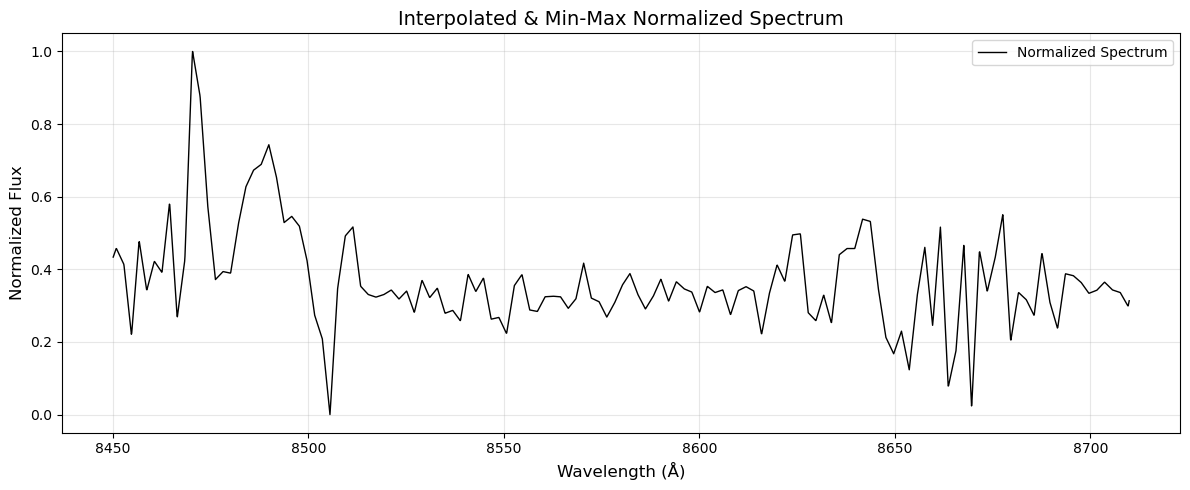

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# =================== 1. 读取 CSV 文件 ===================
csv_file = r'D:\Spectra_denoise\spectrum_final\interpolated_normalized_spectrum.csv'
df = pd.read_csv(csv_file)

wavelength = df['wavelength']
flux_normalized = df['flux_normalized']

print(f"共 {len(df)} 个数据点")
print(f"波长范围: {wavelength.min():.2f} - {wavelength.max():.2f} Å")

# =================== 2. 绘图 ===================
plt.figure(figsize=(12, 5))  # 宽图更适合光谱
plt.plot(wavelength, flux_normalized, color='black', linewidth=1, label='Normalized Spectrum')

# 可选：添加一些美化
plt.xlabel('Wavelength (Å)', fontsize=12)
plt.ylabel('Normalized Flux', fontsize=12)
plt.title('Interpolated & Min-Max Normalized Spectrum', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

# 调整布局，防止标签被遮挡
plt.tight_layout()

# 显示图形
plt.show()